<a href="https://colab.research.google.com/github/felicity8899/ds-classes/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [28]:
# 1. Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 2. Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.0001
EPOCHS = 30
HIDDEN_SIZES = 256
DROPOUT_RATE = 0.4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [29]:
# 3. Data Preparation
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [30]:
# Load Datasets

# 50,000 training data, 10,000 validation data, 10,000 testing data
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [31]:
# 4. Model Architecture
class FashionMLP(nn.Module):
    def __init__(self):
        super(FashionMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, HIDDEN_SIZES),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HIDDEN_SIZES, 10)
        )

    def forward(self, x):
        logits = self.network(x)
        return logits

model = FashionMLP().to(DEVICE)

# 5. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 6. Training Loop
train_losses = []
val_losses = []
val_accuracies = []
best_val_loss = float('inf')

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Backward pass and optimize
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    epoch_train_loss = train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_train_loss:.4f}")

    # 7. Evaluation
    model.eval()
    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()


    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (val_correct / len(val_loader.dataset)) * 100
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), 'model_proj1.pth')

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.2f}%")

Starting Training...
Epoch [1/30], Loss: 0.8628
Epoch [01/30] | Train Loss: 0.8628 | Val Loss: 0.6023 | Val Acc: 79.22%
Epoch [2/30], Loss: 0.5841
Epoch [02/30] | Train Loss: 0.5841 | Val Loss: 0.5261 | Val Acc: 81.59%
Epoch [3/30], Loss: 0.5224
Epoch [03/30] | Train Loss: 0.5224 | Val Loss: 0.4866 | Val Acc: 82.99%
Epoch [4/30], Loss: 0.4891
Epoch [04/30] | Train Loss: 0.4891 | Val Loss: 0.4588 | Val Acc: 83.83%
Epoch [5/30], Loss: 0.4633
Epoch [05/30] | Train Loss: 0.4633 | Val Loss: 0.4414 | Val Acc: 84.51%
Epoch [6/30], Loss: 0.4446
Epoch [06/30] | Train Loss: 0.4446 | Val Loss: 0.4329 | Val Acc: 84.78%
Epoch [7/30], Loss: 0.4302
Epoch [07/30] | Train Loss: 0.4302 | Val Loss: 0.4153 | Val Acc: 85.25%
Epoch [8/30], Loss: 0.4176
Epoch [08/30] | Train Loss: 0.4176 | Val Loss: 0.4023 | Val Acc: 85.62%
Epoch [9/30], Loss: 0.4068
Epoch [09/30] | Train Loss: 0.4068 | Val Loss: 0.3964 | Val Acc: 85.83%
Epoch [10/30], Loss: 0.3985
Epoch [10/30] | Train Loss: 0.3985 | Val Loss: 0.3898 | Val 

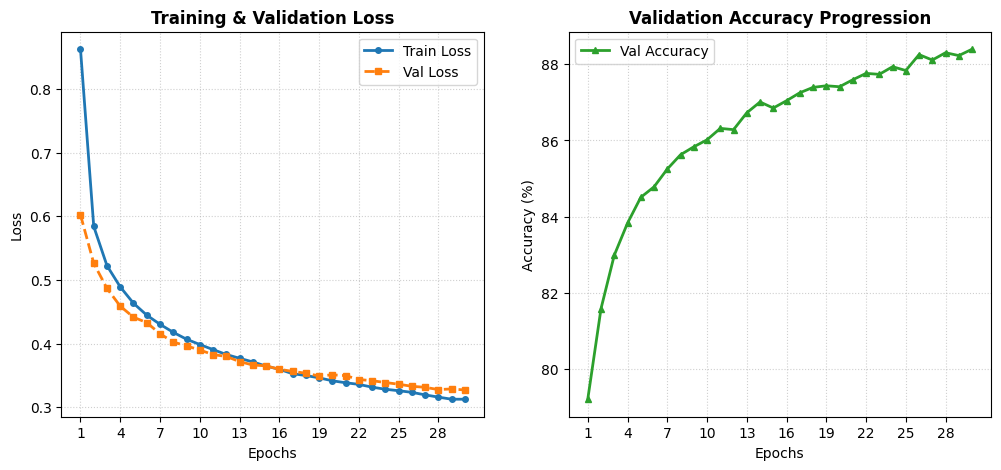

In [32]:
actual_epochs = len(train_losses)
epochs_range = range(1, actual_epochs + 1)

plt.figure(figsize=(12, 5))

# 1 Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--', marker='s', markersize=4)
plt.title('Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, actual_epochs + 1, max(1, actual_epochs//10)))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 2 Validation Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label='Val Accuracy', color='#2ca02c', linewidth=2, marker='^', markersize=4)
plt.title('Validation Accuracy Progression', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(range(1, actual_epochs + 1, max(1, actual_epochs//10)))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [33]:
print("\n=== Final Test Evaluation ===")

# 1. Reload the best model weights saved during the validation phase
model.load_state_dict(torch.load('model_proj1.pth', weights_only=True))

# 2. Switch to evaluation mode (disables Dropout, freezes BatchNorm)
model.eval()

test_loss = 0.0
test_correct = 0

# 3. Disable gradient calculation for memory efficiency and stable inference
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        test_correct += (preds == labels).sum().item()

# 4. Calculate and display final metrics
final_test_loss = test_loss / len(test_loader.dataset)
final_test_acc = (test_correct / len(test_loader.dataset)) * 100

print(f"Total Test Samples: {len(test_loader.dataset)}")
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")


=== Final Test Evaluation ===
Total Test Samples: 10000
Final Test Loss: 0.3437
Final Test Accuracy: 87.62%
